# 13 — Embeddings v5: real-valued-only drift

**v4 finding:** `cosine` on one-hot diff vectors under shift dynamics gives
cos = -1/2 by construction. The v2 "k=1 sign flip" was a measurement artifact,
not a property of Collatz dynamics. **Force is the only lens whose temporal
behavior cosine can meaningfully measure.**

**v5 question:** if we restrict the embedding to *only* the real-valued lenses
(`force` and `slope_log`), and re-run v2's force-binned drift test, does
high-force quad analogy now anchor through iteration?

This actually tests v2's original question, with a clean metric.

**Setup:** same 60 quads (same seed) as nb 10/11/12. Compute drift in the
6-dim real-only subspace (2 lenses x 3 components). Bin quads by mean force
into tertiles, plot drift per bin.


In [1]:
import sys
sys.path.insert(0, '..')
import random
import numpy as np
import matplotlib.pyplot as plt

from collatz.embeddings import Concept, Phi, T_syracuse
from collatz.embeddings.lenses import force
from collatz.embeddings.distance import cosine
from collatz.embeddings.iteration import _syr_step


## 1. Build the real-only weight vector

Per-component axes within Phi (D=73):
- sector: [0, 12)
- mod3: [12, 15)
- drop_class: [15, 47)
- alpha_prefix: [47, 71)
- **force: [71, 72)**
- **slope_log: [72, 73)**

Real-only mask: 1 at indices 71, 72 within each component, 0 elsewhere.


In [2]:
M = 3
D = 73

def keep_real_weights(m=M, d=D):
    w = np.zeros(m * d, dtype=np.float64)
    for i in range(m):
        w[i*d + 71] = 1.0  # force
        w[i*d + 72] = 1.0  # slope_log
    return w

W_real = keep_real_weights()
print(f"real-only weights: {int(W_real.sum())} non-zero axes (expected: 6 = 2 lenses x 3 components)")
print(f"non-zero indices: {np.nonzero(W_real)[0].tolist()}")


real-only weights: 6 non-zero axes (expected: 6 = 2 lenses x 3 components)
non-zero indices: [71, 72, 144, 145, 217, 218]


## 2. Same quad pool as nb 10


In [3]:
random.seed(7)
N_QUADS = 60

def random_triple(lo, hi):
    return tuple(random.randrange(lo, hi) | 1 for _ in range(3))

def shift(c: Concept) -> Concept:
    return Concept(c.name + "*", tuple(_syr_step(x) for x in c.vec))

quads = []
for i in range(N_QUADS):
    scale = random.choice([10, 50, 200, 1000, 5000])
    a = Concept(f"a{i}", random_triple(2, scale))
    c = Concept(f"c{i}", random_triple(2, scale))
    quads.append((a, shift(a), c, shift(c)))

quad_force = np.array([
    np.mean([force(n) for con in (a, b, c, d) for n in con.vec])
    for a, b, c, d in quads
])
print(f"force range: {quad_force.min():.1f} - {quad_force.max():.1f}, median {np.median(quad_force):.1f}")


force range: 2.7 - 24.2, median 5.4


## 3. Compute drift curves in real-only subspace


In [4]:
def iterate(c: Concept, k: int) -> Concept:
    for _ in range(k):
        c = T_syracuse(c)
    return c

def real_cosine(diff_a: np.ndarray, diff_b: np.ndarray) -> float:
    return cosine(diff_a * W_real, diff_b * W_real)

K = 8
drift = np.zeros((N_QUADS, K + 1))
for q_idx, (a, b, c, d) in enumerate(quads):
    base_diff = Phi(b) - Phi(a)
    for k in range(K + 1):
        ak = iterate(a, k)
        bk = iterate(b, k)
        diff_k = Phi(bk) - Phi(ak)
        drift[q_idx, k] = real_cosine(diff_k, base_diff)

print(f"Mean drift over k=1..K (real-only): {drift[:, 1:].mean():+.3f}")
print(f"Sign flips at k=1: {(drift[:, 1] < 0).sum()}/{N_QUADS}")
print(f"Mean k=1 cosine: {drift[:, 1].mean():+.3f}")
print(f"Mean k=K cosine: {drift[:, K].mean():+.3f}")


Mean drift over k=1..K (real-only): -0.014
Sign flips at k=1: 32/60
Mean k=1 cosine: -0.091
Mean k=K cosine: +0.102


## 4. Bin by force tertile


In [5]:
t1, t2 = np.percentile(quad_force, [33.33, 66.67])
bins = np.digitize(quad_force, [t1, t2])

bin_label = {0: f"low force (<= {t1:.1f})", 1: f"mid force ({t1:.1f}-{t2:.1f})", 2: f"high force (> {t2:.1f})"}
bin_color = {0: "tab:red", 1: "tab:orange", 2: "tab:blue"}

print(f"bin sizes: low={int((bins==0).sum())}, mid={int((bins==1).sum())}, high={int((bins==2).sum())}")
print()
print(f"{'k':>3} {'low':>10} {'mid':>10} {'high':>10} {'high - low':>12}")
print("-" * 50)
for k in range(K + 1):
    low = drift[bins == 0, k].mean()
    mid = drift[bins == 1, k].mean()
    high = drift[bins == 2, k].mean()
    print(f"{k:>3} {low:>10.3f} {mid:>10.3f} {high:>10.3f} {high - low:>+12.3f}")


bin sizes: low=20, mid=20, high=20

  k        low        mid       high   high - low
--------------------------------------------------
  0      0.950      1.000      1.000       +0.050
  1      0.040     -0.104     -0.210       -0.250
  2     -0.088     -0.176     -0.035       +0.054
  3     -0.013     -0.112     -0.064       -0.052
  4      0.224      0.380     -0.018       -0.242
  5     -0.356     -0.339     -0.171       +0.185
  6      0.059      0.106      0.011       -0.048
  7      0.123      0.026      0.079       -0.044
  8      0.016      0.181      0.109       +0.093


## 5. Plot


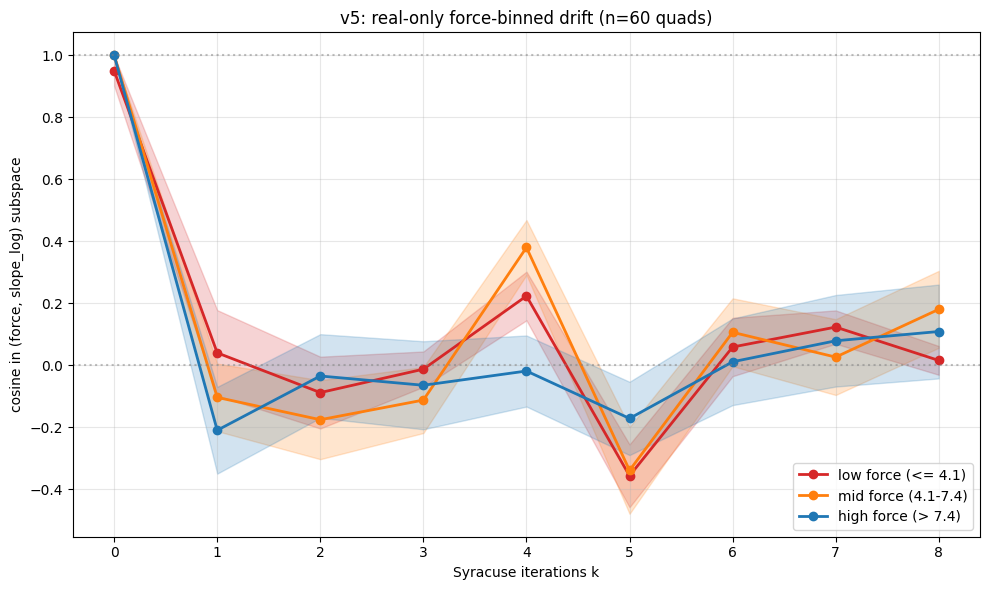

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ks = np.arange(K + 1)
for b_idx in [0, 1, 2]:
    mask = bins == b_idx
    if mask.sum() == 0: continue
    curves = drift[mask]
    mean = curves.mean(axis=0)
    se = curves.std(axis=0) / np.sqrt(curves.shape[0])
    ax.plot(ks, mean, marker="o", color=bin_color[b_idx], label=bin_label[b_idx], linewidth=2)
    ax.fill_between(ks, mean - se, mean + se, color=bin_color[b_idx], alpha=0.2)

ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.axhline(1, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Syracuse iterations k")
ax.set_ylabel("cosine in (force, slope_log) subspace")
ax.set_title(f"v5: real-only force-binned drift (n={N_QUADS} quads)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Verdict template

- **High - low consistently positive and growing/sustained**: v1's epistemic-confidence
  interpretation is back. Force-rich quads do anchor analogies through iteration --
  it's just that the v2 measurement was poisoned by one-hots.
- **High - low ~ 0**: bin-binned drift has no signal even with the clean metric. Force
  is a static analogy carrier but doesn't differentially anchor through iteration.
- **High - low negative**: low-force quads preserve longer; would mean force = "narrow
  subgroup" actually makes concepts MORE susceptible to iteration drift, not less.
